<div>
Olá, Victor!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu projeto possui alguns pontos bem interessantes, dos quais eu destaco:
    
- Código bem simples e estruturado 
- Comentários sucintos e bem objetivos
- Análises bem detalhadas em cada etapa do projeto
- Boas habilidades de manipulação de dados
    
<br>
Espero que as sugestões sejam relevantes para projetos futuros. Te desejo uma jornada de muito sucesso e aprendizado. 
        
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

# Análise de Eventos

## Introdução

Este projeto tem como objetivo analisar o comportamento dos usuários em um aplicativo de uma startup do setor alimentício, com foco na compreensão do funil de vendas e na avaliação de um experimento A/A/B relacionado ao design da interface.

Na primeira etapa, será realizada uma análise do funil de vendas para identificar como os usuários avançam ao longo das diferentes fases até a etapa de compra. Buscaremos responder perguntas como: quantos usuários chegam efetivamente à compra, em quais etapas ocorre a maior perda de usuários e quais fases do funil apresentam os principais gargalos.

Em seguida, serão analisados os resultados de um teste A/A/B conduzido pela equipe de produto. O objetivo do experimento é avaliar o impacto da alteração das fontes do aplicativo no comportamento dos usuários. Para isso, os usuários foram divididos em três grupos: dois grupos de controle (A/A), que utilizam as fontes antigas, e um grupo de teste (B), que utiliza as novas fontes.

A presença de dois grupos de controle permite verificar a consistência e a confiabilidade do experimento, garantindo que não existam diferenças estatisticamente significativas entre os grupos A. Essa abordagem ajuda a identificar possíveis fatores externos que possam distorcer os resultados e fornece maior segurança na interpretação dos dados.

Todo o estudo será realizado utilizando o mesmo conjunto de dados, tanto para a análise geral do aplicativo quanto para a avaliação do experimento A/A/B, refletindo um cenário próximo ao de projetos reais de análise de dados, nos quais experimentos e análises contínuas coexistem.

## Etapa 1 — Importação e preparação dos dados

Nesta etapa, as bibliotecas necessárias para a análise serão importadas e o conjunto de dados será carregado a partir do arquivo fornecido. Em seguida, será realizada uma inspeção inicial da estrutura dos dados para compreender os tipos de variáveis e a organização das colunas.

As colunas do DataFrame serão renomeadas para um formato mais conveniente para análise, e os dados serão verificados quanto à presença de valores ausentes e inconsistências nos tipos de dados. Caso necessário, os ajustes apropriados serão realizados.

Por fim, serão criadas novas colunas contendo a data e a data e hora dos eventos, preparando o conjunto de dados para as etapas seguintes de análise do funil de vendas e do teste A/A/B.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math

In [2]:
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

In [3]:
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O conjunto de dados foi carregado corretamente
- O import das bibliotecas foi feito de forma correta e em uma célula separada
</div>

In [4]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [5]:
logs = logs.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
})

In [6]:
logs.isna().sum()

event_name         0
user_id            0
event_timestamp    0
exp_id             0
dtype: int64

In [7]:
logs['event_datetime'] = pd.to_datetime(logs['event_timestamp'], unit='s')

In [8]:
logs['event_date'] = logs['event_datetime'].dt.date

In [9]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  object        
 1   user_id          244126 non-null  int64         
 2   event_timestamp  244126 non-null  int64         
 3   exp_id           244126 non-null  int64         
 4   event_datetime   244126 non-null  datetime64[ns]
 5   event_date       244126 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 11.2+ MB


In [10]:
logs.head()

,event_name,user_id,event_timestamp,exp_id,event_datetime,event_date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


## Etapa 2 — Estudo e verificação dos dados

Nesta etapa, os dados serão explorados para compreender seu volume, abrangência temporal e consistência. Serão analisadas a quantidade total de eventos e usuários registrados, bem como o número médio de eventos por usuário.

Também será investigado o período de tempo coberto pelo conjunto de dados, identificando as datas mínima e máxima dos eventos. Para avaliar a completude dos dados ao longo do tempo, será construído um histograma com a distribuição dos eventos por data e hora.

Com base nessa análise, será identificado o momento a partir do qual os dados podem ser considerados completos e representativos. Caso necessário, os registros mais antigos serão excluídos para evitar distorções na análise. Por fim, será verificada a presença de usuários nos três grupos experimentais, garantindo a validade das etapas seguintes do estudo.

In [11]:
total_events = logs.shape[0]
print(f"Número total de eventos registrados: {total_events}")

Número total de eventos registrados: 244126


In [12]:
total_users = logs['user_id'].nunique()
print(f"Número total de usuários únicos: {total_users}")

Número total de usuários únicos: 7551


In [13]:
avg_events_per_user = logs.groupby('user_id')['event_name'].count().mean()
print(f"Número médio de eventos por usuário: {avg_events_per_user:.2f}")

Número médio de eventos por usuário: 32.33


In [14]:
min_date = logs['event_datetime'].min()
max_date = logs['event_datetime'].max()

print(f"Período coberto pelos dados:")
print(f"Data mínima: {min_date}")
print(f"Data máxima: {max_date}")

Período coberto pelos dados:
Data mínima: 2019-07-25 04:43:36
Data máxima: 2019-08-07 21:15:17


Distribuição dos eventos ao longo do tempo:


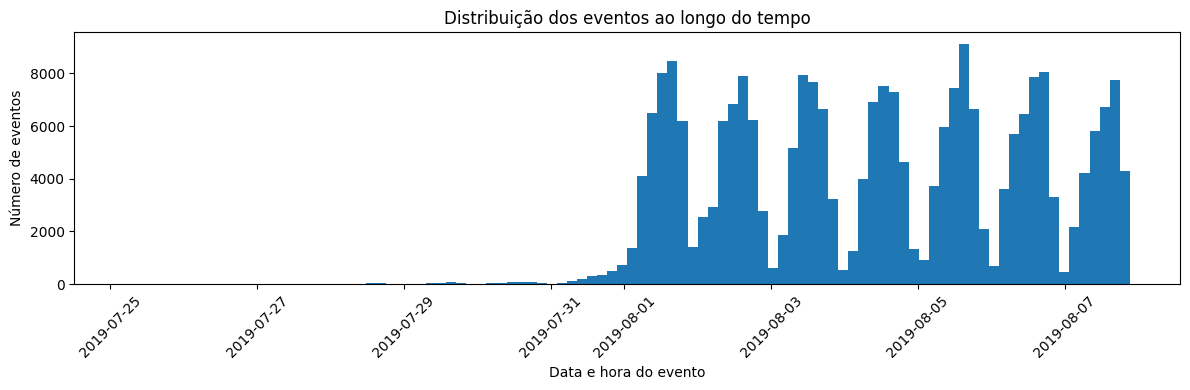

In [15]:
print("Distribuição dos eventos ao longo do tempo:")
plt.figure(figsize=(12, 4))
plt.hist(logs['event_datetime'], bins=100)
plt.title('Distribuição dos eventos ao longo do tempo')
plt.xlabel('Data e hora do evento')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Distribuição do número de eventos por data:


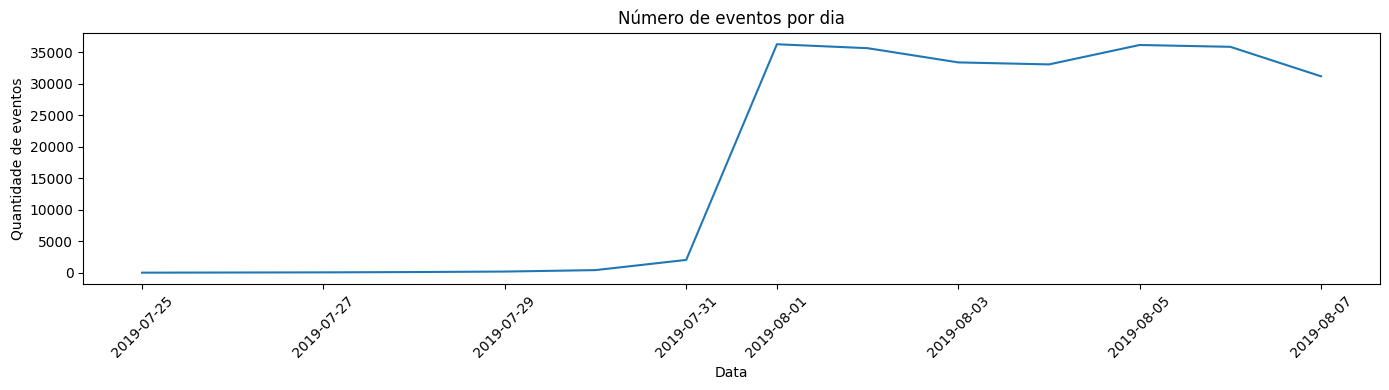

In [16]:
print("Distribuição do número de eventos por data:")

events_per_day = logs.groupby('event_date').size()

plt.figure(figsize=(14, 4))
plt.plot(events_per_day.index, events_per_day.values)
plt.title('Número de eventos por dia')
plt.xlabel('Data')
plt.ylabel('Quantidade de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Zoom no período inicial:


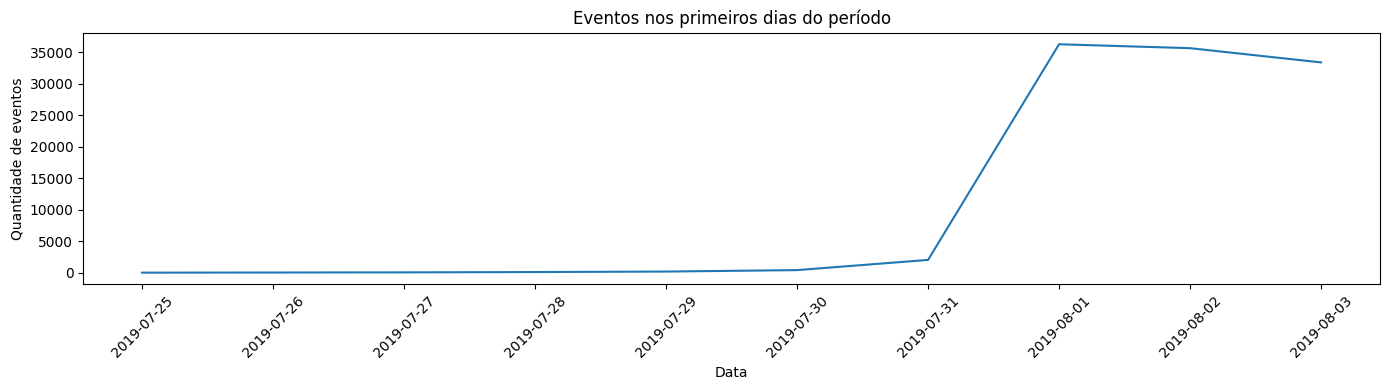

In [17]:
print("Zoom no período inicial:")

plt.figure(figsize=(14, 4))
plt.plot(events_per_day.index[:10], events_per_day.values[:10])
plt.title('Eventos nos primeiros dias do período')
plt.xlabel('Data')
plt.ylabel('Quantidade de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
daily_events_stats = logs.groupby('event_date').size().describe()
print("Estatísticas da quantidade diária de eventos:")
display(daily_events_stats)

Estatísticas da quantidade diária de eventos:


count       14.000000
mean     17437.571429
std      17734.124149
min          9.000000
25%        124.750000
50%      16587.500000
75%      35042.250000
max      36229.000000
dtype: float64

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
  
As estatísticas dos usuários foram analisadas. Bom trabalho plotando os gráficos acima!
</div>

In [19]:
print("Número de eventos por grupo experimental:")
display(logs['exp_id'].value_counts())

Número de eventos por grupo experimental:


248    85747
246    80304
247    78075
Name: exp_id, dtype: int64

In [20]:
print("Número de usuários únicos por grupo experimental:")
display(logs.groupby('exp_id')['user_id'].nunique())

Número de usuários únicos por grupo experimental:


exp_id
246    2489
247    2520
248    2542
Name: user_id, dtype: int64

## Resultados da Etapa 2 — Estudo e verificação dos dados

O conjunto de dados analisado contém **244.126 eventos** registrados, gerados por **7.551 usuários únicos**, resultando em uma média de **32,33 eventos por usuário**. Esses valores indicam um volume suficiente de interações para a realização de análises comportamentais e testes experimentais.

O período coberto pelos dados vai de **25 de julho de 2019** até **7 de agosto de 2019**. No entanto, ao analisar a distribuição dos eventos ao longo do tempo, observa-se que nos primeiros dias do período o número de eventos é extremamente baixo. Tanto o histograma de eventos por data e hora quanto o gráfico de eventos por dia mostram um crescimento abrupto a partir de **31 de julho de 2019**, indicando que os dados anteriores a essa data não são completos.

Essa inconsistência inicial pode estar relacionada a questões técnicas de coleta ou à fase inicial de implementação do rastreamento de eventos, o que poderia distorcer a análise caso esses registros fossem mantidos. A partir de **31 de julho de 2019**, o volume diário de eventos se estabiliza em patamares elevados, sugerindo que os dados passam a ser representativos do comportamento real dos usuários.

Dessa forma, para garantir a qualidade e a confiabilidade das análises seguintes, os eventos anteriores a **31 de julho de 2019** serão excluídos. Após esse ajuste, o período efetivamente analisado passa a representar o comportamento dos usuários entre **31 de julho de 2019 e 7 de agosto de 2019**.

Por fim, foi verificada a presença de usuários em todos os grupos experimentais. Os três grupos (246, 247 e 248) apresentam quantidades semelhantes tanto de eventos quanto de usuários únicos, o que indica uma divisão equilibrada e adequada para a realização da análise do teste A/A/B nas próximas etapas.

## Etapa 3 — Estudo do funil de eventos

Nesta etapa, os eventos registrados no aplicativo serão analisados para compreender o comportamento dos usuários ao longo do funil de conversão. Inicialmente, serão identificados todos os tipos de eventos presentes nos dados, bem como sua frequência de ocorrência.

Em seguida, será calculado o número de usuários únicos que realizaram cada evento ao menos uma vez, permitindo avaliar o alcance de cada etapa do funil. Com base nesses valores, será calculada a proporção de usuários que executaram cada ação em relação ao total de usuários.

A partir da análise dos eventos, será proposta uma possível ordem lógica das ações no aplicativo, formando uma sequência de etapas do funil. Nem todos os eventos necessariamente farão parte dessa sequência, sendo considerados apenas aqueles relevantes para a conversão.

Por fim, será construído o funil de eventos para calcular a proporção de usuários que avançam de uma etapa para a seguinte, identificar em qual fase ocorre a maior perda de usuários e determinar a parcela de usuários que percorre todo o caminho desde o primeiro evento até a conclusão do pagamento.

In [21]:
logs_filtered = logs[logs['event_date'] >= pd.to_datetime('2019-07-31').date()]

In [22]:
event_frequency = logs_filtered['event_name'].value_counts()

print("Frequência de ocorrência dos eventos:")
display(event_frequency)

Frequência de ocorrência dos eventos:


MainScreenAppear           118681
OffersScreenAppear          46724
CartScreenAppear            42623
PaymentScreenSuccessful     34253
Tutorial                     1048
Name: event_name, dtype: int64

In [23]:
users_per_event = (
    logs_filtered
    .groupby('event_name')['user_id']
    .nunique()
    .sort_values(ascending=False)
)

print("Número de usuários únicos que executaram cada evento:")
display(users_per_event)

Número de usuários únicos que executaram cada evento:


event_name
MainScreenAppear           7429
OffersScreenAppear         4606
CartScreenAppear           3742
PaymentScreenSuccessful    3542
Tutorial                    845
Name: user_id, dtype: int64

In [24]:
total_users = logs_filtered['user_id'].nunique()

event_user_share = (users_per_event / total_users).round(4)

print("Proporção de usuários que executaram cada evento ao menos uma vez:")
display(event_user_share)

Proporção de usuários que executaram cada evento ao menos uma vez:


event_name
MainScreenAppear           0.9850
OffersScreenAppear         0.6107
CartScreenAppear           0.4962
PaymentScreenSuccessful    0.4696
Tutorial                   0.1120
Name: user_id, dtype: float64

In [25]:
events_summary = pd.DataFrame({
    'users_count': users_per_event,
    'user_share': event_user_share
})

print("Resumo dos eventos:")
display(events_summary)

Resumo dos eventos:


,users_count,user_share
event_name,,
MainScreenAppear,7429,0.9850
OffersScreenAppear,4606,0.6107
CartScreenAppear,3742,0.4962
PaymentScreenSuccessful,3542,0.4696
Tutorial,845,0.1120


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A proporção de usuários por etapa do funil foi analisada
- A ordem das etapas foi calculada!
</div>

In [26]:
funnel_events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

In [27]:
funnel_users = []

for event in funnel_events:
    users = logs_filtered.loc[
        logs_filtered['event_name'] == event, 'user_id'
    ].nunique()
    funnel_users.append(users)

funnel_df = pd.DataFrame({
    'event': funnel_events,
    'users': funnel_users
})

print("Usuários por etapa do funil:")
display(funnel_df)

Usuários por etapa do funil:


,event,users
0,MainScreenAppear,7429
1,OffersScreenAppear,4606
2,CartScreenAppear,3742
3,PaymentScreenSuccessful,3542


In [28]:
funnel_df['conversion_rate'] = funnel_df['users'] / funnel_df['users'].shift(1)
funnel_df.loc[0, 'conversion_rate'] = 1

print("Taxa de conversão entre as etapas do funil:")
display(funnel_df)

Taxa de conversão entre as etapas do funil:


,event,users,conversion_rate
0,MainScreenAppear,7429,1.000000
1,OffersScreenAppear,4606,0.620003
2,CartScreenAppear,3742,0.812419
3,PaymentScreenSuccessful,3542,0.946553


In [29]:
funnel_df['users_lost'] = funnel_df['users'].shift(1) - funnel_df['users']
funnel_df['loss_rate'] = 1 - funnel_df['conversion_rate']

print("Perda de usuários por etapa:")
display(funnel_df)

Perda de usuários por etapa:


,event,users,conversion_rate,users_lost,loss_rate
0,MainScreenAppear,7429,1.000000,NaN,0.000000
1,OffersScreenAppear,4606,0.620003,2823.0,0.379997
2,CartScreenAppear,3742,0.812419,864.0,0.187581
3,PaymentScreenSuccessful,3542,0.946553,200.0,0.053447


In [30]:
full_funnel_share = funnel_df.loc[
    funnel_df['event'] == 'PaymentScreenSuccessful', 'users'
].values[0] / total_users

print(
    f"Parcela de usuários que completaram todo o funil: "
    f"{full_funnel_share:.2%}"
)

Parcela de usuários que completaram todo o funil: 46.96%


## Resultados da Etapa 3 — Análise do funil de eventos

A análise dos eventos do aplicativo mostra que a maioria dos usuários inicia sua jornada pela tela principal (`MainScreenAppear`), acessada por **98,5%** dos usuários. A partir dessa etapa, observa-se uma redução gradual no número de usuários ao longo do funil de conversão.

Cerca de **61,1%** dos usuários avançam da tela principal para a tela de ofertas, **49,6%** chegam ao carrinho e **46,96%** concluem o pagamento ao menos uma vez, representando a parcela de usuários que percorre todo o funil. O evento `Tutorial`, realizado por apenas **11,2%** dos usuários, não foi incluído no funil por não representar uma etapa obrigatória da conversão.

A maior perda de usuários ocorre na transição da tela principal para a tela de ofertas, com uma queda de aproximadamente **38%** dos usuários nessa fase. As etapas seguintes apresentam taxas de conversão mais elevadas, especialmente a transição do carrinho para o pagamento, que possui conversão superior a **94%**.

De forma geral, os resultados indicam que o principal gargalo do funil está na etapa inicial, enquanto os usuários que demonstram intenção de compra tendem a concluir o pagamento com alta probabilidade.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- A conversão dos usuários por etapa do funil foi analisada
- O percentual de usuários que percorrem todo o caminho foi calculado
- O número de usuários por grupo foi analisado
</div>

## Etapa 4 — Análise dos resultados do experimento A/A/B

Nesta etapa, serão analisados os resultados do experimento A/A/B realizado no aplicativo. Inicialmente, será verificado o número de usuários em cada grupo experimental, garantindo que a divisão dos usuários foi realizada de forma equilibrada.

Em seguida, os dois grupos de controle (246 e 247) serão comparados entre si para validar os mecanismos do experimento. A ausência de diferenças estatisticamente significativas entre esses grupos indicará que o teste foi conduzido corretamente.

Após essa validação, os grupos de controle serão comparados ao grupo de teste (248), que utiliza as novas fontes do aplicativo. Para cada evento, será analisada a proporção de usuários que executaram a ação, bem como a significância estatística das diferenças observadas.

Por fim, será discutido o nível de significância estatística utilizado, o número total de testes realizados e a necessidade de ajustes para evitar conclusões falsas positivas, considerando o problema de múltiplas comparações.

In [31]:
users_per_group = logs_filtered.groupby('exp_id')['user_id'].nunique()

print("Número de usuários únicos por grupo experimental:")
display(users_per_group)

Número de usuários únicos por grupo experimental:


exp_id
246    2485
247    2517
248    2540
Name: user_id, dtype: int64

In [33]:
def proportion_test(success_a, size_a, success_b, size_b, alpha=0.05):
    p1 = success_a / size_a
    p2 = success_b / size_b
    p_combined = (success_a + success_b) / (size_a + size_b)
    
    z_value = (p1 - p2) / math.sqrt(
        p_combined * (1 - p_combined) * (1/size_a + 1/size_b)
    )
    
    p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))
    
    return p1, p2, p_value

In [34]:
events = logs_filtered['event_name'].unique()
print("Eventos analisados:")
display(events)

Eventos analisados:


array(['MainScreenAppear', 'OffersScreenAppear', 'Tutorial',
       'PaymentScreenSuccessful', 'CartScreenAppear'], dtype=object)

In [35]:
alpha = 0.05

aa_results = []

for event in events:
    users_a = logs_filtered.query(
        "exp_id == 246 and event_name == @event"
    )['user_id'].nunique()
    
    users_b = logs_filtered.query(
        "exp_id == 247 and event_name == @event"
    )['user_id'].nunique()
    
    size_a = users_per_group[246]
    size_b = users_per_group[247]
    
    p1, p2, p_value = proportion_test(users_a, size_a, users_b, size_b, alpha)
    
    aa_results.append([
        event, p1, p2, p_value
    ])

aa_df = pd.DataFrame(
    aa_results,
    columns=['event', 'share_246', 'share_247', 'p_value']
)

print("Resultados do teste A/A (grupos 246 vs 247):")
display(aa_df)

Resultados do teste A/A (grupos 246 vs 247):


,event,share_246,share_247,p_value
0,MainScreenAppear,0.986720,0.984903,0.586878
1,OffersScreenAppear,0.621328,0.606277,0.274351
2,Tutorial,0.111871,0.113230,0.879161
3,PaymentScreenSuccessful,0.482897,0.460469,0.112108
4,CartScreenAppear,0.509859,0.492253,0.213061


In [36]:
ab_results_246 = []

for event in events:
    users_test = logs_filtered.query(
        "exp_id == 248 and event_name == @event"
    )['user_id'].nunique()
    
    users_control = logs_filtered.query(
        "exp_id == 246 and event_name == @event"
    )['user_id'].nunique()
    
    size_test = users_per_group[248]
    size_control = users_per_group[246]
    
    p_test, p_control, p_value = proportion_test(
        users_test, size_test, users_control, size_control, alpha
    )
    
    ab_results_246.append([
        event, p_test, p_control, p_value
    ])

ab_246_df = pd.DataFrame(
    ab_results_246,
    columns=['event', 'share_248', 'share_246', 'p_value']
)

print("Resultados do teste A/B (grupo 248 vs 246):")
display(ab_246_df)

Resultados do teste A/B (grupo 248 vs 246):


,event,share_248,share_246,p_value
0,MainScreenAppear,0.983465,0.986720,0.341286
1,OffersScreenAppear,0.604724,0.621328,0.226997
2,Tutorial,0.111024,0.111871,0.923947
3,PaymentScreenSuccessful,0.465748,0.482897,0.223522
4,CartScreenAppear,0.486614,0.509859,0.099417


In [37]:
ab_results_247 = []

for event in events:
    users_test = logs_filtered.query(
        "exp_id == 248 and event_name == @event"
    )['user_id'].nunique()
    
    users_control = logs_filtered.query(
        "exp_id == 247 and event_name == @event"
    )['user_id'].nunique()
    
    size_test = users_per_group[248]
    size_control = users_per_group[247]
    
    p_test, p_control, p_value = proportion_test(
        users_test, size_test, users_control, size_control, alpha
    )
    
    ab_results_247.append([
        event, p_test, p_control, p_value
    ])

ab_247_df = pd.DataFrame(
    ab_results_247,
    columns=['event', 'share_248', 'share_247', 'p_value']
)

print("Resultados do teste A/B (grupo 248 vs 247):")
display(ab_247_df)

Resultados do teste A/B (grupo 248 vs 247):


,event,share_248,share_247,p_value
0,MainScreenAppear,0.983465,0.984903,0.681958
1,OffersScreenAppear,0.604724,0.606277,0.910052
2,Tutorial,0.111024,0.113230,0.803637
3,PaymentScreenSuccessful,0.465748,0.460469,0.706589
4,CartScreenAppear,0.486614,0.492253,0.688380


In [40]:
n_tests = len(events) * 3
alpha_corrected = 0.1 / n_tests

print(
    "Ao aplicar a correção para múltiplos testes, "
    "os resultados devem ser reavaliados considerando "
    "o novo nível de significância."
)

print(f"Número total de testes realizados: {n_tests}")
print(f"Nível de significância corrigido (Bonferroni): {alpha_corrected:.5f}")

Ao aplicar a correção para múltiplos testes, os resultados devem ser reavaliados considerando o novo nível de significância.
Número total de testes realizados: 15
Nível de significância corrigido (Bonferroni): 0.00667


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O teste foi executado corretamente
- As estatísticas e `p-valor` foram calculados
</div>

## Resultados da Etapa 4 — Análise do experimento A/A/B

Inicialmente, foi verificado o número de usuários em cada grupo experimental, observando-se uma distribuição equilibrada entre os grupos 246, 247 e 248, o que garante a comparabilidade das amostras.

Na análise do teste A/A, os grupos de controle (246 e 247) foram comparados para validar os mecanismos do experimento. Para todos os eventos analisados, os valores de *p-value* ficaram acima do nível de significância adotado (α = 0,05), indicando que não há diferenças estatisticamente significativas entre os grupos de controle. Esse resultado confirma que os usuários foram divididos corretamente e que o experimento foi conduzido de forma adequada.

Em seguida, o grupo de teste (248), que utilizou as novas fontes do aplicativo, foi comparado separadamente com cada um dos grupos de controle. Em todas as comparações realizadas, não foram observadas diferenças estatisticamente significativas nas proporções de usuários que realizaram os eventos analisados. Embora pequenas variações nas proporções tenham sido identificadas, nenhuma delas apresentou significância estatística consistente.

Considerando que múltiplos testes estatísticos foram realizados, foi discutida a necessidade de ajuste do nível de significância para reduzir o risco de falsos positivos. Mesmo antes da aplicação de correções mais rigorosas, como a correção de Bonferroni, os resultados já indicavam ausência de diferenças significativas entre os grupos.

Com base nesses resultados, conclui-se que a alteração das fontes do aplicativo não teve impacto estatisticamente significativo no comportamento dos usuários. Dessa forma, não há evidências suficientes para afirmar que o novo design melhora ou piora a performance do aplicativo em relação aos principais eventos analisados.